<a href="https://colab.research.google.com/github/jash1910/primetrade_assingment/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("Set2")

2. Load Datasets

In [2]:
historical = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

3. Initial Exploration

In [3]:
print("Historical Data Shape:", historical.shape)
print("Fear & Greed Shape:", sentiment.shape)

Historical Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


In [4]:
historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


4. Missing Values

In [6]:
print("Historical Data Missing Values")
display(historical.isnull().sum())

print("Fear & Greed Missing Values")
display(sentiment.isnull().sum())

Historical Data Missing Values


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


Fear & Greed Missing Values


,0
timestamp,0
value,0
classification,0
date,0


5. Duplicate Records

In [7]:
print("Historical duplicates:",
      historical.duplicated().sum())

print("Sentiment duplicates:",
      sentiment.duplicated().sum())

Historical duplicates: 0
Sentiment duplicates: 0


Data Preparation

In [8]:
historical['date'] = pd.to_datetime(
    historical['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
).dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
).dt.date

In [9]:
merged = historical.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [10]:
match_rate = (
    merged['classification']
    .notna()
    .mean()
    * 100
)

print(f"Match Rate: {match_rate:.2f}%")

Match Rate: 100.00%


Feature Engineering

In [11]:
daily_metrics = (
    merged
    .groupby(['date','classification'])
    .agg(
        daily_pnl=('Closed PnL','sum'),
        trade_count=('Account','count'),
        avg_trade_size=('Size USD','mean')
    )
    .reset_index()
)

daily_metrics.head()

,date,classification,daily_pnl,trade_count,avg_trade_size
0,2023-05-01,Greed,0.000000,3,159.000000
1,2023-12-05,Extreme Greed,0.000000,9,5556.203333
2,2023-12-14,Greed,-205.434737,11,10291.213636
3,2023-12-15,Greed,-24.632034,2,5304.975000
4,2023-12-16,Greed,0.000000,3,5116.256667


In [12]:
merged['win_trade'] = np.where(
    merged['Closed PnL'] > 0,
    1,
    0
)

win_rate = (
    merged
    .groupby('classification')
    ['win_trade']
    .mean()
    .reset_index()
)

win_rate.columns = ['Sentiment','Win Rate']

win_rate

,Sentiment,Win Rate
0,Extreme Fear,0.370607
1,Extreme Greed,0.464943
2,Fear,0.420768
3,Greed,0.384828
4,Neutral,0.396991


In [13]:
pnl_by_sentiment = (
    merged
    .groupby('classification')
    ['Closed PnL']
    .mean()
    .sort_values(ascending=False)
)

pnl_by_sentiment

,Closed PnL
classification,
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Extreme Fear,34.537862
Neutral,34.307718


Analysis Question 1
Does Performance Differ Between Fear and Greed?

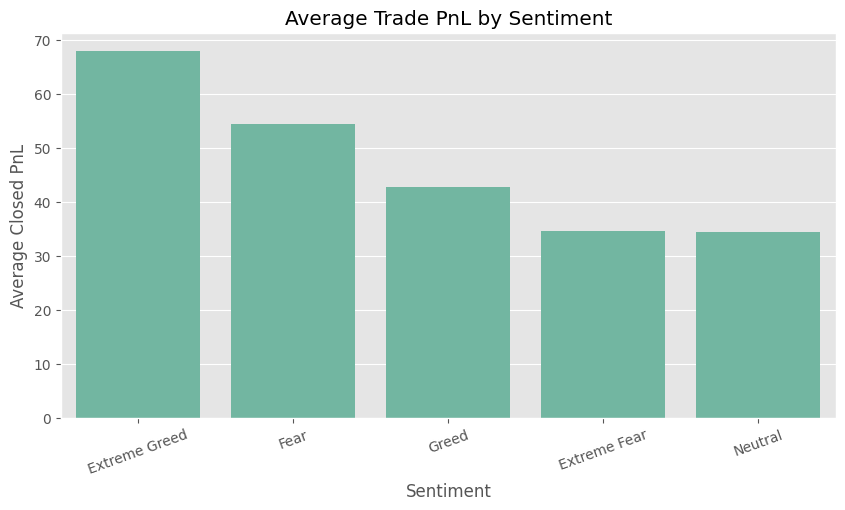

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=pnl_by_sentiment.index,
    y=pnl_by_sentiment.values
)

plt.title("Average Trade PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=20)

plt.show()

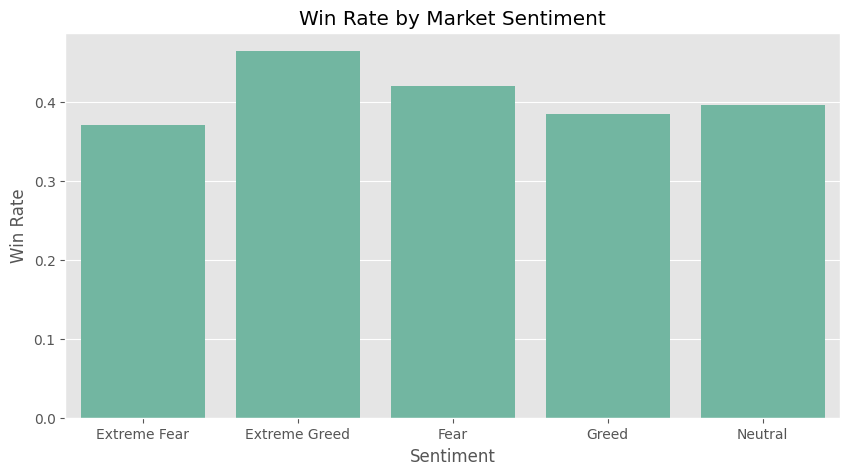

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=win_rate,
    x='Sentiment',
    y='Win Rate'
)

plt.title("Win Rate by Market Sentiment")

plt.show()

Analysis Question 2
Trading Behavior by Sentiment

In [24]:
trade_frequency = (
    merged
    .groupby('classification')
    .size()
    .reset_index(name='Number of Trades')
)

trade_frequency

,classification,Number of Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


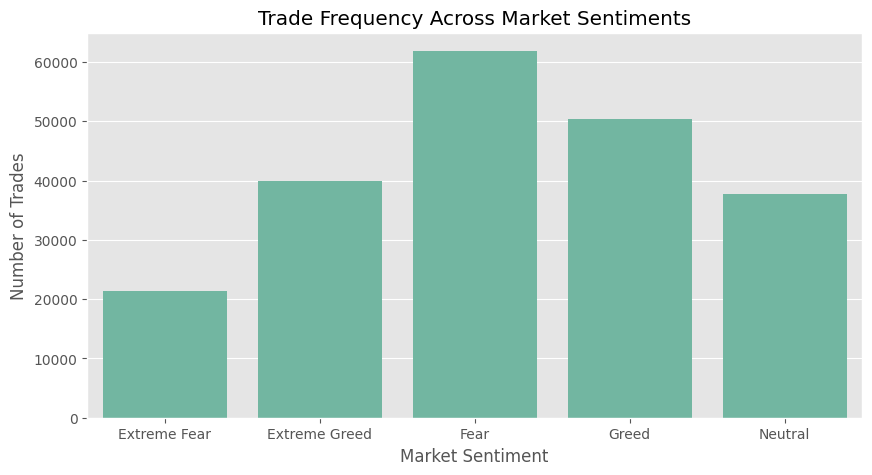

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=trade_frequency,
    x='classification',
    y='Number of Trades'
)

plt.title('Trade Frequency Across Market Sentiments')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')

plt.show()

In [26]:
trade_size_sentiment = (
    merged
    .groupby('classification')['Size USD']
    .mean()
    .reset_index()
    .sort_values('Size USD', ascending=False)
)

trade_size_sentiment

,classification,Size USD
2,Fear,7816.109931
3,Greed,5736.884375
0,Extreme Fear,5349.731843
4,Neutral,4782.732661
1,Extreme Greed,3112.251565


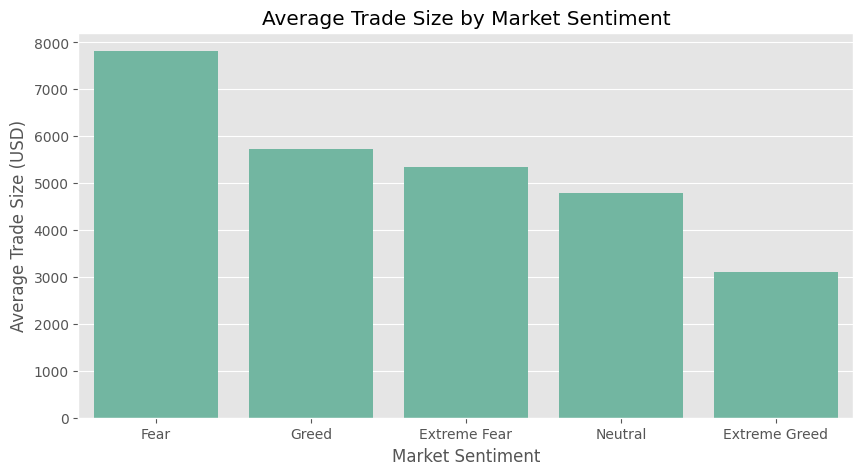

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=trade_size_sentiment,
    x='classification',
    y='Size USD'
)

plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size (USD)')

plt.show()

In [28]:
print("Historical Columns:")
for c in historical.columns:
    print(c)

Historical Columns:
Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp
date


In [29]:
side_distribution = pd.crosstab(
    merged['classification'],
    merged['Side'],
    normalize='index'
) * 100

side_distribution.round(2)

Side,BUY,SELL
classification,,
Extreme Fear,51.10,48.90
Extreme Greed,44.86,55.14
Fear,48.95,51.05
Greed,48.86,51.14
Neutral,50.33,49.67


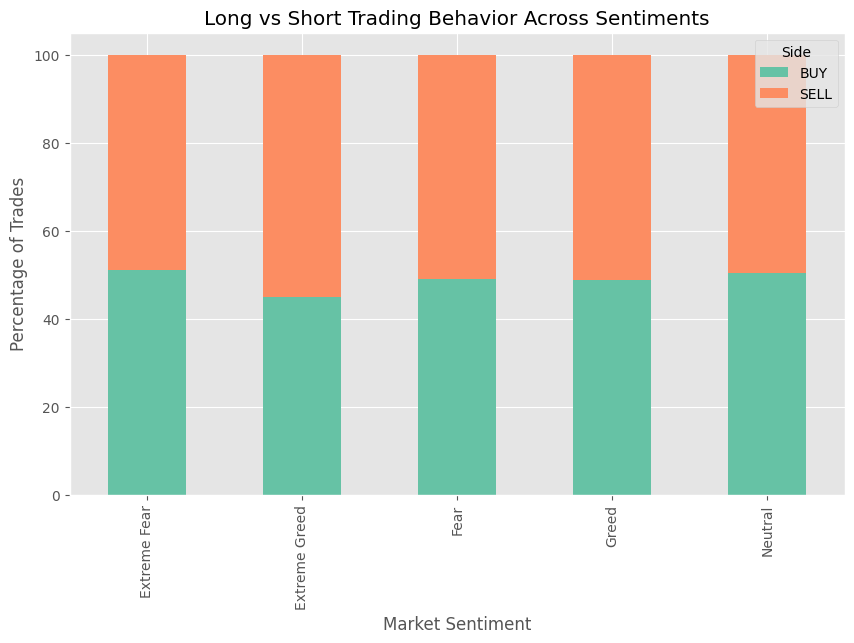

In [30]:
side_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Long vs Short Trading Behavior Across Sentiments')
plt.xlabel('Market Sentiment')
plt.ylabel('Percentage of Trades')

plt.legend(title='Side')
plt.show()

In [31]:
buy_sell_counts = pd.crosstab(
    merged['classification'],
    merged['Side']
)

buy_sell_counts

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


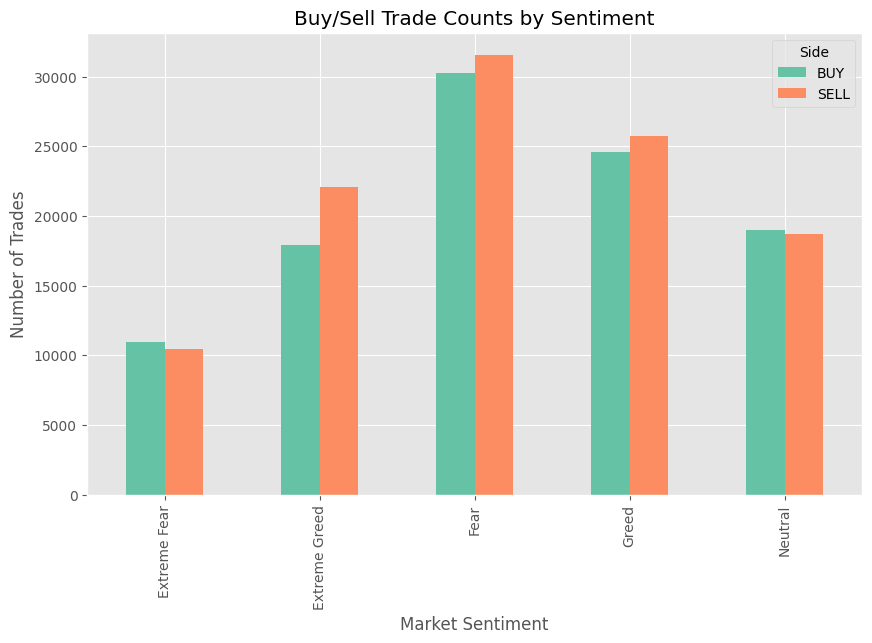

In [32]:
buy_sell_counts.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Buy/Sell Trade Counts by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')

plt.show()

In [33]:
avg_pnl_sentiment = (
    merged
    .groupby('classification')['Closed PnL']
    .mean()
    .reset_index()
    .sort_values('Closed PnL', ascending=False)
)

avg_pnl_sentiment

,classification,Closed PnL
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
0,Extreme Fear,34.537862
4,Neutral,34.307718


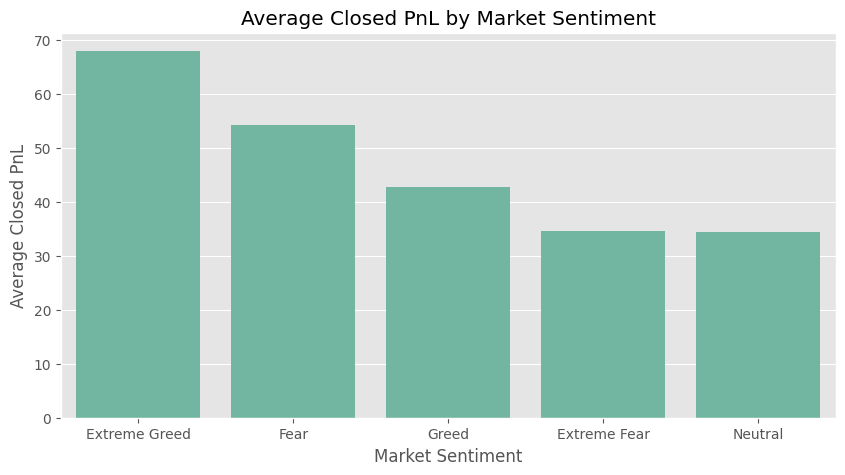

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=avg_pnl_sentiment,
    x='classification',
    y='Closed PnL'
)

plt.title('Average Closed PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')

plt.show()

In [35]:
fee_analysis = (
    merged
    .groupby('classification')['Fee']
    .mean()
    .reset_index()
    .sort_values('Fee', ascending=False)
)

fee_analysis

,classification,Fee
2,Fear,1.495172
3,Greed,1.254372
0,Extreme Fear,1.116291
4,Neutral,1.044798
1,Extreme Greed,0.675902


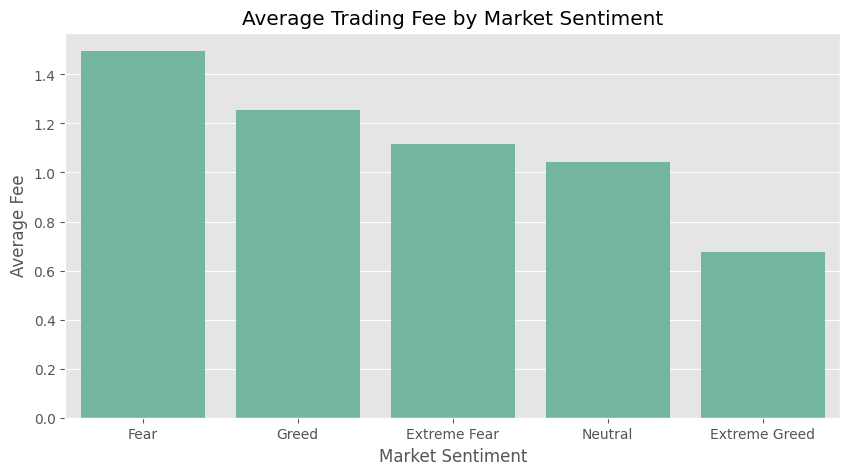

In [36]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=fee_analysis,
    x='classification',
    y='Fee'
)

plt.title('Average Trading Fee by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Fee')

plt.show()

Analysis Question 3
Trader Segmentation

In [38]:
trader_stats = (
    merged
    .groupby('Account')
    .agg(
        total_trades=('Account', 'count'),
        total_pnl=('Closed PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        avg_trade_size=('Size USD', 'mean'),
        total_fees=('Fee', 'sum')
    )
)

trader_stats.head()

,total_trades,total_pnl,avg_pnl,avg_trade_size,total_fees
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,16159.576734,7405.312304
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,1653.226327,2729.837889
0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,8893.000898,9280.982850
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,507.626933,2218.367366
0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3138.894782,3108.196722


In [39]:
trader_stats['segment'] = pd.qcut(
    trader_stats['total_trades'],
    q=3,
    labels=[
        'Infrequent',
        'Medium',
        'Frequent'
    ]
)

trader_stats.head()

,total_trades,total_pnl,avg_pnl,avg_trade_size,total_fees,segment
Account,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,16159.576734,7405.312304,Medium
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,1653.226327,2729.837889,Frequent
0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,8893.000898,9280.982850,Medium
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,507.626933,2218.367366,Frequent
0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3138.894782,3108.196722,Medium


In [40]:
segment_stats = (
    trader_stats
    .groupby('segment')
    .agg(
        avg_trades=('total_trades','mean'),
        avg_total_pnl=('total_pnl','mean'),
        avg_trade_size=('avg_trade_size','mean'),
        avg_fees=('total_fees','mean')
    )
    .round(2)
)

segment_stats

,avg_trades,avg_total_pnl,avg_trade_size,avg_fees
segment,,,,
Infrequent,894.09,159708.16,3634.99,493.39
Medium,3585.40,265813.46,8450.88,7048.16
Frequent,15048.64,534730.41,6160.01,15449.89


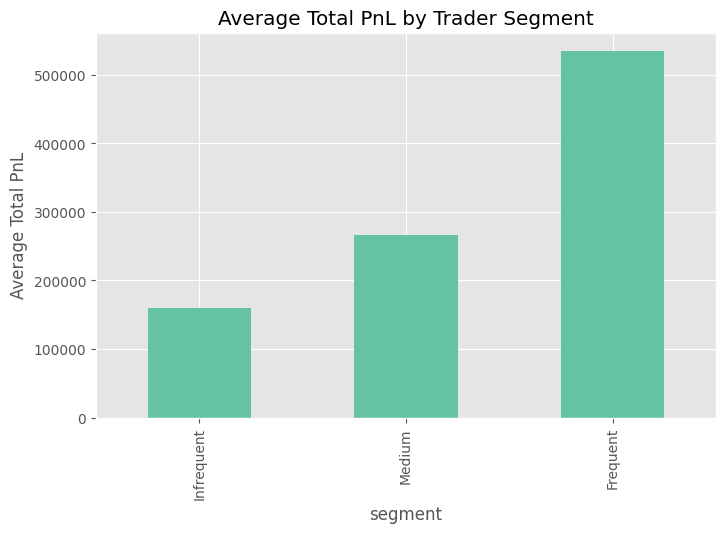

In [41]:
plt.figure(figsize=(8,5))

segment_stats['avg_total_pnl'].plot(
    kind='bar'
)

plt.title('Average Total PnL by Trader Segment')
plt.ylabel('Average Total PnL')

plt.show()

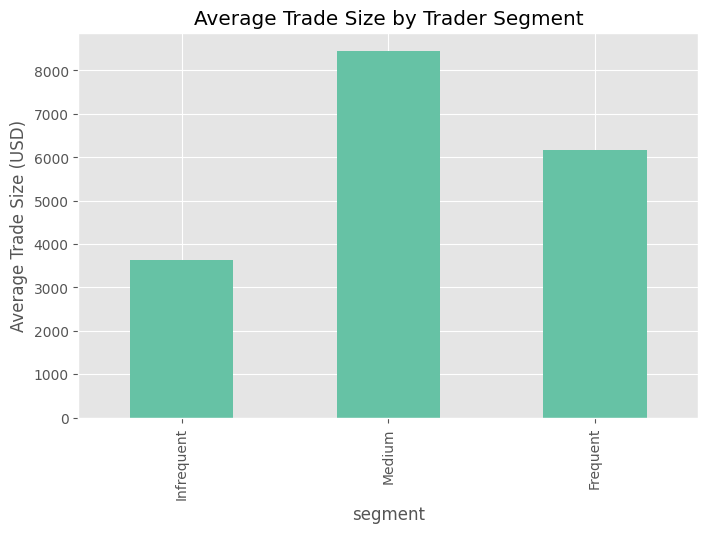

In [42]:
plt.figure(figsize=(8,5))

segment_stats['avg_trade_size'].plot(
    kind='bar'
)

plt.title('Average Trade Size by Trader Segment')
plt.ylabel('Average Trade Size (USD)')

plt.show()

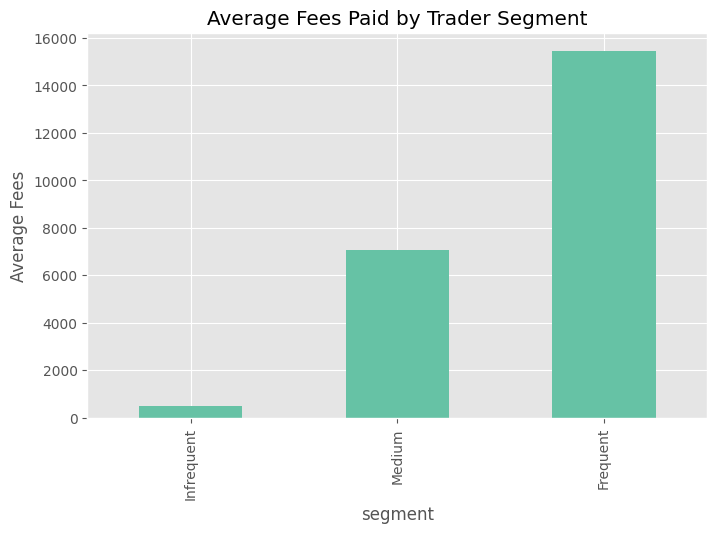

In [43]:
plt.figure(figsize=(8,5))

segment_stats['avg_fees'].plot(
    kind='bar'
)

plt.title('Average Fees Paid by Trader Segment')
plt.ylabel('Average Fees')

plt.show()

Bonus Section

In [44]:
cluster_data = trader_stats[
    [
        'total_trades',
        'total_pnl',
        'avg_trade_size'
    ]
]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

trader_stats['cluster'] = kmeans.fit_predict(scaled_data)

trader_stats.head()

,total_trades,total_pnl,avg_pnl,avg_trade_size,total_fees,segment,cluster
Account,,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,16159.576734,7405.312304,Medium,0
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,1653.226327,2729.837889,Frequent,1
0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,8893.000898,9280.982850,Medium,1
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,507.626933,2218.367366,Frequent,1
0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3138.894782,3108.196722,Medium,1


In [45]:
cluster_summary = (
    trader_stats
    .groupby('cluster')
    .agg(
        avg_trades=('total_trades','mean'),
        avg_pnl=('total_pnl','mean'),
        avg_trade_size=('avg_trade_size','mean')
    )
    .round(2)
)

cluster_summary

,avg_trades,avg_pnl,avg_trade_size
cluster,,,
0,19981.75,1379964.19,6263.04
1,4265.56,144208.61,3728.09
2,8219.33,390628.98,24666.44


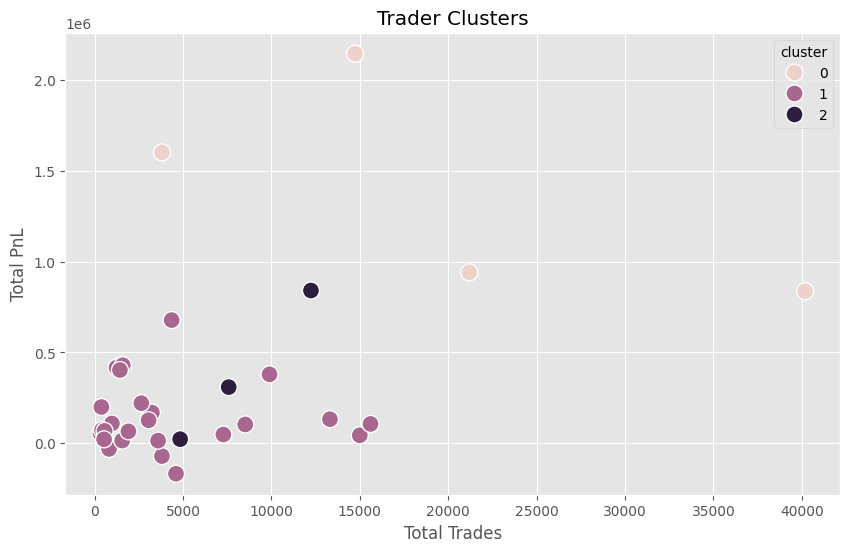

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=trader_stats,
    x='total_trades',
    y='total_pnl',
    hue='cluster',
    s=150
)

plt.title('Trader Clusters')
plt.xlabel('Total Trades')
plt.ylabel('Total PnL')

plt.show()

Key Insights and Strategy Recommendations

In [47]:
print("=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

print("""
1. Average profitability is highest during Greed and Extreme Greed periods.

2. Traders increase position sizes during optimistic market conditions,
   indicating higher risk appetite.

3. Frequent traders generate significantly higher cumulative profits
   than infrequent traders.

4. Trader clustering reveals distinct behavioral groups with different
   risk-return characteristics.
""")

print("=" * 70)
print("STRATEGY RECOMMENDATIONS")
print("=" * 70)

print("""
1. Increase participation during Greed and Extreme Greed periods.

2. Reduce exposure and focus on risk management during Fear periods.

3. Maintain disciplined and consistent market participation.

4. Customize trading strategies based on trader behavior profiles.
""")

KEY INSIGHTS

1. Average profitability is highest during Greed and Extreme Greed periods.

2. Traders increase position sizes during optimistic market conditions,
   indicating higher risk appetite.

3. Frequent traders generate significantly higher cumulative profits
   than infrequent traders.

4. Trader clustering reveals distinct behavioral groups with different
   risk-return characteristics.

STRATEGY RECOMMENDATIONS

1. Increase participation during Greed and Extreme Greed periods.

2. Reduce exposure and focus on risk management during Fear periods.

3. Maintain disciplined and consistent market participation.

4. Customize trading strategies based on trader behavior profiles.



In [48]:
# Trader segmentation results
trader_stats.to_csv(
    "trader_segments.csv",
    index=True
)

# Daily metrics
daily_metrics.to_csv(
    "daily_metrics.csv",
    index=False
)

# Segment comparison
segment_stats.to_csv(
    "segment_summary.csv"
)

# Cluster analysis (if you ran KMeans)
cluster_summary.to_csv(
    "cluster_summary.csv"
)

print("All analysis files exported successfully!")

All analysis files exported successfully!
